# Day 2 — DBSCAN & Hierarchical Clustering

## Customer Segmentation Using Clustering Algorithms

## Step 1 — Import Libraries

In this step, we import the libraries needed for data loading, visualization, scaling, clustering, and evaluation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster




## Step 2 — Load the Dataset

We load the Mall Customers dataset using Pandas.

The dataset contains customer information such as gender, age, annual income, and spending score.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Step 3 — Select Features for Clustering

For clustering, we use:

- **Annual Income (k$):** the customer's annual income.
- **Spending Score (1-100):** the customer's spending behavior.

We do not use `CustomerID` because it is only an identifier and does not provide meaningful information for clustering.

In [5]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

## Step 4 — Feature Scaling

Clustering algorithms are distance-based, so features should be on a similar scale.

We use `StandardScaler` to standardize the features so that they have approximately:

- Mean = 0
- Standard deviation = 1

This is especially important for DBSCAN and hierarchical clustering because both rely on distances.

In [6]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Step 5 — DBSCAN Clustering

DBSCAN is a density-based clustering algorithm.

It groups points that are close together and located in dense regions.

Important parameters:

- `eps=0.5`: defines the maximum distance between neighboring points.
- `min_samples=5`: minimum number of nearby points required to form a dense region.

Unlike K-Means, DBSCAN does not require us to specify the number of clusters beforehand.

In [7]:
dbscan =DBSCAN(
    eps=0.5,
    min_samples=5
)
dbscan_labels =dbscan.fit_predict(X_scaled)

## Step 6 — Count DBSCAN Clusters and Noise

DBSCAN assigns the label `-1` to points considered noise.

We calculate:

- The number of clusters.
- The number of noise points.

The `-1` label is excluded from the cluster count.

In [8]:
n_clusters = len(set(dbscan_labels)) - (
    1 if -1 in dbscan_labels else 0
    )

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 2
Number of noise points: 8


## Step 7 — Visualize DBSCAN Clustering

We visualize the DBSCAN results using a scatter plot.

Each color represents a different cluster, while the noise points are assigned the label `-1`.

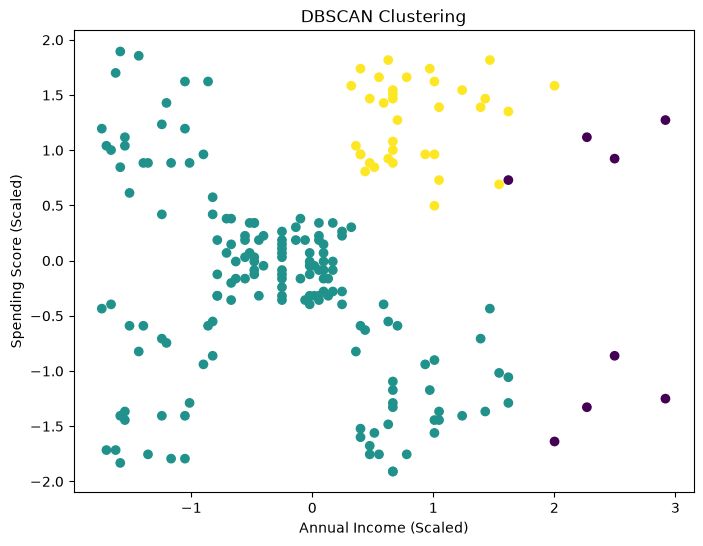

In [9]:

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels
)

plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.title("DBSCAN Clustering")

plt.show()

### DBSCAN Clustering Visualization

The scatter plot below shows the customer clusters identified using **DBSCAN** based on scaled Annual Income and Spending Score.

- Each color represents a different cluster.
- Points labeled as noise are identified by DBSCAN as potential outliers.
- The plot helps visualize the distribution and separation of customer groups.

## Step 8 — Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters by progressively merging the closest observations.

We use the **Ward linkage method**, which tries to minimize the variance within each cluster.

The result is stored in `Z`, which will be used to create the dendrogram.

In [10]:

Z = linkage(
    X_scaled,
    method="ward"
)

## Step 9 — Dendrogram

A dendrogram visualizes the hierarchical clustering process.

It shows how individual customers are progressively merged into larger clusters.

The vertical axis represents the distance at which clusters are merged.

We can use the dendrogram to decide where to cut the hierarchy and determine the number of clusters.

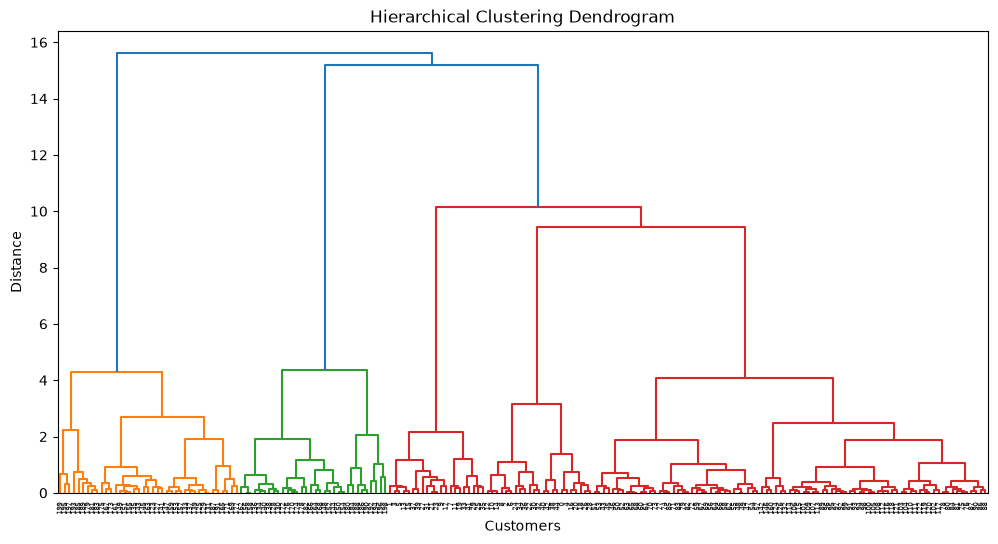

In [11]:
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

### Hierarchical Clustering Dendrogram

The dendrogram  visualizes the hierarchical relationships between customers based on their scaled Annual Income and Spending Score.

- The vertical axis represents the distance between clusters.
- Customers are progressively merged into larger clusters.
- The dendrogram helps determine an appropriate number of clusters by selecting a distance threshold.

## Step 10 — Create Hierarchical Clusters

We use `fcluster()` to cut the hierarchical tree at a specified distance.

Here, we use:

`distance = 12`

This means that clusters are formed by cutting the dendrogram at a distance of 12.

In [12]:
hierarchical_labels = fcluster(
    Z,
    t=12,
    criterion="distance"
)

## Step 11 — Count Hierarchical Clusters

We count the unique cluster labels produced by hierarchical clustering.

With a distance threshold of `12`, the algorithm produces 3 clusters.

In [20]:


n_clusters_hierarchical = len(set(hierarchical_labels))

print(
    "Number of hierarchical clusters:",
    n_clusters_hierarchical
)

Number of hierarchical clusters: 3


### Hierarchical Clustering — Number of Clusters

The Hierarchical Clustering algorithm produced:

**3 clusters**

## Step 12 — Evaluate DBSCAN Using Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

Its value ranges from approximately `-1` to `1`.

- A value close to `1` indicates well-separated clusters.
- A value close to `0` indicates overlapping clusters.
- A negative value may indicate poor clustering.

For DBSCAN, we exclude noise points (`-1`) before calculating the score.

In [13]:
mask = dbscan_labels != -1

silhouette_dbscan = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print(
    "DBSCAN Silhouette Score:",
    silhouette_dbscan
)

DBSCAN Silhouette Score: 0.3875583892728279


### DBSCAN — Silhouette Score

The **Silhouette Score** for DBSCAN is:

**0.3876**

This indicates **moderate clustering quality**, with some overlap between the clusters.

## Step 13 — Evaluate Hierarchical Clustering

We calculate the Silhouette Score for the hierarchical clustering results.

This allows us to compare the quality of the hierarchical clusters with the DBSCAN clusters.

In [14]:
silhouette_hierarchical = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    silhouette_hierarchical
)

Hierarchical Silhouette Score: 0.4610481446570447


### Hierarchical Clustering — Silhouette Score

The **Silhouette Score** for Hierarchical Clustering is:

**0.4610**

This indicates a **moderate clustering quality**, meaning the clusters are reasonably well separated, but there is still some overlap between them.

## Step 14 — Compare Clustering Results

We compare DBSCAN and Hierarchical Clustering based on:

- Number of clusters.
- Number of noise points.
- Silhouette Score.

DBSCAN identified 2 clusters and 8 noise points, while hierarchical clustering identified 3 clusters using a distance threshold of 12.

The Silhouette Score can help us determine which clustering result provides better separation between clusters.

In [21]:
print("DBSCAN")
print("Clusters:", n_clusters)
print("Noise points:", n_noise)
print("Silhouette Score:", silhouette_dbscan)

print("\nHierarchical Clustering")
print("Clusters:", n_clusters_hierarchical)
print("Silhouette Score:", silhouette_hierarchical)

DBSCAN
Clusters: 2
Noise points: 8
Silhouette Score: 0.3875583892728279

Hierarchical Clustering
Clusters: 3
Silhouette Score: 0.4610481446570447


## Clustering Comparison

The results show that DBSCAN produced 2 clusters and identified 8 noise points, with a Silhouette Score of 0.388.

Hierarchical Clustering produced 3 clusters with a higher Silhouette Score of 0.461.

Since the Hierarchical Clustering model has a higher Silhouette Score, it provides better cluster separation and cohesion for this dataset under the selected parameters.

However, DBSCAN has the advantage of identifying noise points, while Hierarchical Clustering assigns every customer to a cluster.

## Conclusion

DBSCAN and Hierarchical Clustering produced different clustering structures because they use different approaches.

- **DBSCAN** is density-based and can identify noise points.
- **Hierarchical Clustering** is distance-based and creates a hierarchy of clusters.
- The dendrogram helps determine an appropriate distance threshold.
- The Silhouette Score helps evaluate and compare the quality of the resulting clusters.

Therefore, the best clustering method should be selected based on both the evaluation score and the meaningfulness of the resulting customer groups.